In [1]:
import h5py
import json

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression, SGDRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
import time
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split

In [2]:
with h5py.File('solutions.h5', 'r') as f:
    # List all groups/datasets
    dataset = f["data"]   # This does NOT load data
    dataset = dataset[:]
    print(dataset.shape)        # Fast
    coef = f["coeffs"]
    coef = coef[:]
    print(coef.shape)

(8000, 64, 128, 1)
(8000, 4)


In [4]:
# read out-of-distribution dataset
with h5py.File('ood.h5', 'r') as f_ood:
    # List all groups/datasets
    dataset_ood = f_ood["data"]   # This does NOT load data
    dataset_ood = dataset_ood[:]
    print(dataset_ood.shape)        # Fast
    coef_ood = f_ood["coeffs"]
    coef_ood = coef_ood[:]
    
X_ood = dataset_ood[:,0,:,0]
Y_ood = dataset_ood[:,:,:,0]
print(X_ood.shape, Y_ood.shape, coef_ood.shape)

(2000, 64, 128, 1)
(2000, 128) (2000, 64, 128) (2000, 4)


(400, 4)

# Framework 1

In [23]:
coef_fr1 = coef[::20]
# get training and test datasets
num0 = int(0.8 * coef_fr1.shape[0])
num0_test = coef_fr1.shape[0] - num0

X_train = coef_fr1[:num0]
X_test = coef_fr1[num0:]


num = int(0.8 * dataset.shape[0])
Y_train = dataset[:num,:,:,0].reshape(num0,20*64*128)
Y_test = dataset[num:,:,:,0]

print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(320, 4) (320, 163840) (80, 4) (1600, 64, 128)


In [28]:
##################### RBF kernel
bandwidth = 0.1
kernel = RBF(length_scale = bandwidth)
model = GaussianProcessRegressor(kernel, alpha = 1e-10, optimizer=None)

model.fit(X_train, Y_train)

pred = model.predict(X_test)
pred = pred.reshape(Y_test.shape)

# reshape prediction and Y_test
e = np.mean(np.linalg.norm(pred - Y_test, axis = (1,2))/np.linalg.norm(Y_test, axis = (1,2)))
print(f'Gaussian kernel: test error is {e:.2e}.\n')    


Gaussian kernel: test error is 1.59e-04.



In [31]:
##################### Matern kernel
bandwidth = 1
nu = 5/2
kernel = Matern(length_scale = bandwidth, nu=nu)
model = GaussianProcessRegressor(kernel, alpha = 1e-10, optimizer=None)

model.fit(X_train, Y_train)

pred = model.predict(X_test)
pred = pred.reshape(Y_test.shape)

# reshape prediction and Y_test
e = np.mean(np.linalg.norm(pred - Y_test, axis = (1,2))/np.linalg.norm(Y_test, axis = (1,2)))
print(f'Matern kernel: test error is {e:.2e}.\n')    


Matern kernel: test error is 1.45e-04.



# Vanilla Kernel

In [34]:
num = int(0.8 * dataset.shape[0])
X_train = dataset[:num,0,:,0]
Y_train = dataset[:num,:,:,0]
X_test = dataset[num:,0,:,0]
Y_test = dataset[num:,:,:,0]
coef_train = coef[:num]
coef_test = coef[num:]
print(X_train.shape, coef_train.shape, Y_train.shape)

##################### RBF kernel
bandwidth = 100
kernel = RBF(length_scale = bandwidth)
model = GaussianProcessRegressor(kernel, alpha = 1e-10, optimizer=None)
model.fit(X_train, Y_train.reshape(num,64*128))

# prediction
pred = model.predict(X_test)
pred = pred.reshape(Y_test.shape)
e = np.mean(np.linalg.norm(pred - Y_test, axis = (1,2))/np.linalg.norm(Y_test, axis = (1,2)))
print(f'Test error is {e:.2e}.\n')

(6400, 128) (6400, 4) (6400, 64, 128)
Test error is 3.72e-02.



In [ ]:
### out-of-distribution testing
ood_pred = model.predict(X_ood)
ood_pred = ood_pred.reshape(2000,64,128)
ood_e = np.mean(np.linalg.norm(ood_pred - Y_ood, axis = (1,2))/np.linalg.norm(Y_ood, axis = (1,2)))
print(f'Out-of-distribution error is {ood_e:.2e}.\n')

# Our Method

In [35]:
# kernel for coefficients
bandwidth1 = 1
nu1 = 5/2
kernel1 = Matern(length_scale = bandwidth1, nu=nu1)
K_c = kernel1(coef_train)

# kernel for u
bandwidth2 = 1
nu2 = 5/2
kernel2 = Matern(length_scale = bandwidth2, nu=nu2)
K_u = kernel2(X_train)

# product kernel
K_train = K_c * K_u

# model
model = KernelRidge(alpha = 1e-10, kernel='precomputed')
model.fit(K_train, Y_train.reshape(num,64*128))

# prediction
K_c_test = kernel1(coef_test, coef_train)
K_u_test = kernel2(X_test, X_train)
K_test = K_c_test * K_u_test
our_pred = model.predict(K_test)
our_pred = our_pred.reshape(Y_test.shape)

# Error
our_e = np.mean(np.linalg.norm(our_pred - Y_test, axis = (1,2))/np.linalg.norm(Y_test, axis = (1,2)))
print(f'Test error of our method is {our_e:.2e}.\n')

Test error of our method is 1.45e-04.



In [11]:
# prediction
K_c_ood = kernel1(coef_ood, coef_train)
K_u_ood = kernel2(X_ood, X_train)
K_ood = K_c_ood * K_u_ood

### out-of-distribution 
our_ood_pred = model.predict(K_ood)
our_ood_pred = our_ood_pred.reshape(2000,64,128)
our_ood_e = np.mean(np.linalg.norm(our_ood_pred - Y_ood, axis = (1,2))/np.linalg.norm(Y_ood, axis = (1,2)))
print(f'Out-of-distribution error is {our_ood_e:.2e}.\n')

Out-of-distribution error is 6.13e-02.



Text(0, 0.5, 't')

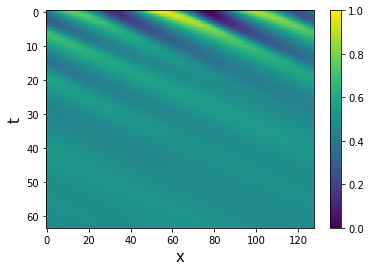

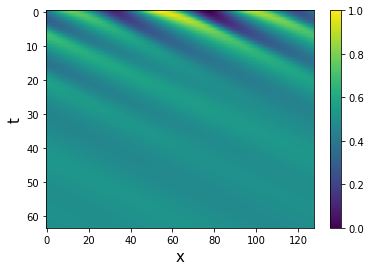

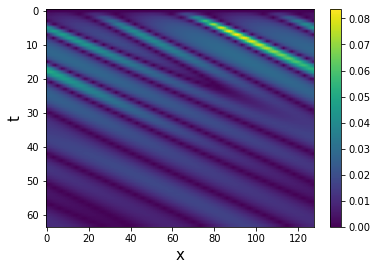

In [12]:
# visualization
idx = 1
plt.figure(1)
plt.imshow(pred[idx],aspect='auto')
plt.colorbar()
plt.xlabel('x',size=15)
plt.ylabel('t',size=15)

plt.figure(2)
plt.imshow(Y_test[idx],aspect='auto')
plt.colorbar()
plt.xlabel('x',size=15)
plt.ylabel('t',size=15)

plt.figure(3)
plt.imshow(abs(pred[idx]-Y_test[idx]),aspect='auto')
plt.colorbar()
plt.xlabel('x',size=15)
plt.ylabel('t',size=15)